# **Topic : Spam SMS Detection ( Classification)**

1. Dataset Loading and Exploration

In [8]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam.csv


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('spam.csv', encoding='latin1')
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [10]:
import pandas as pd
df = pd.read_csv('spam.csv', encoding='latin1')
df = df[['v1','v2']]
df.columns = ['label','message']

print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [11]:
print(df.shape)

(5572, 2)


In [12]:
print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


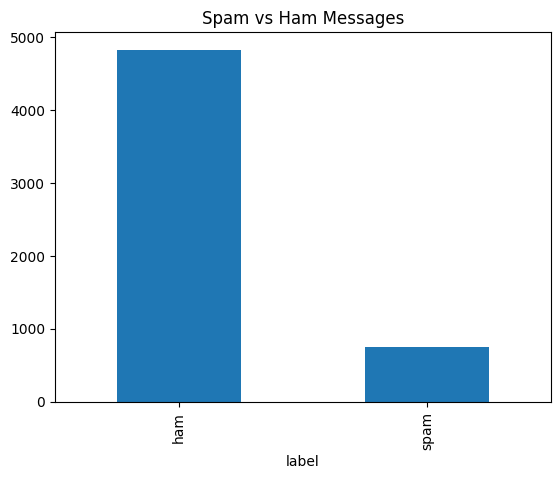

In [13]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Messages")
plt.show()

2. Data Preprocessing

In [14]:
import string

def clean_text(text):

    text = text.lower()

    text = text.translate(str.maketrans('', '', string.punctuation))

    return text

df['clean_message'] = df['message'].apply(clean_text)

In [15]:
data = df.dropna()

In [16]:
print(df.isnull().sum())

label            0
message          0
clean_message    0
dtype: int64


In [17]:
df = df.drop_duplicates()

3. Feature Extraction

In [18]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [19]:
data['label'] = data['label'].map({'ham':0, 'spam':1})

In [20]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(data['message'])

y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9623318385650225


4. Training Multiple Classification Models

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

Model 1: Naive Bayes

In [22]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

Model 2: Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

Model 3: Support Vector Machine

In [24]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

5. Performance Evaluation and Model Comparison

In [25]:
from sklearn.metrics import accuracy_score

print("Naive Bayes Accuracy:", accuracy_score(y_test, pred_nb))

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))

print("SVM Accuracy:", accuracy_score(y_test, pred_svm))

Naive Bayes Accuracy: 0.9623318385650225
Logistic Regression Accuracy: 0.9632286995515695
SVM Accuracy: 0.9766816143497757


6. Best Model Selection

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

nb = MultinomialNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)

lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

svm = SVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

results = {}

results["Naive Bayes"] = accuracy_score(y_test, pred_nb)
results["Logistic Regression"] = accuracy_score(y_test, pred_lr)
results["SVM"] = accuracy_score(y_test, pred_svm)

print("Model Accuracies:")
for model, acc in results.items():
    print(model, ":", acc)

best_model_name = max(results, key=results.get)
best_accuracy = results[best_model_name]

print("\nBest Model is:", best_model_name)
print("Accuracy:", best_accuracy)

if best_model_name == "Naive Bayes":
    best_model = nb
elif best_model_name == "Logistic Regression":
    best_model = lr
elif best_model_name == "SVM":
    best_model = svm

Model Accuracies:
Naive Bayes : 0.9555125725338491
Logistic Regression : 0.9555125725338491
SVM : 0.9796905222437138

Best Model is: SVM
Accuracy: 0.9796905222437138



### Outlier Detection based on Message Length

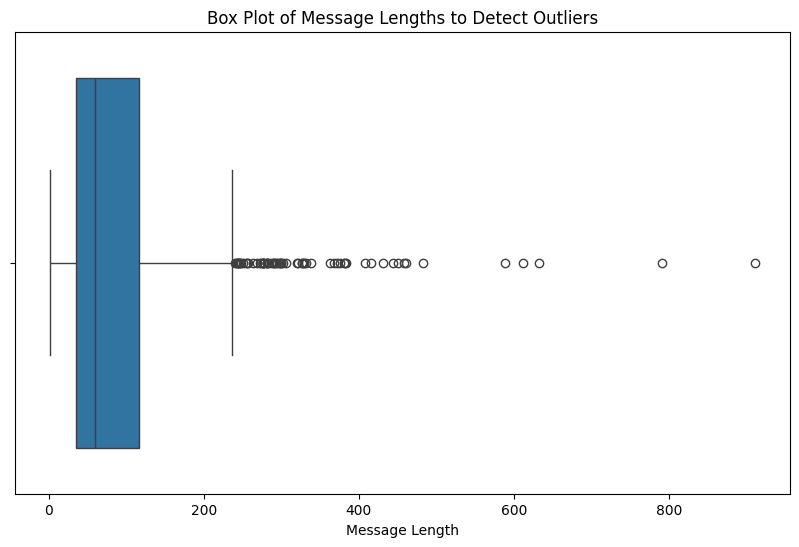

count    5169.000000
mean       78.977945
std        58.236293
min         2.000000
25%        36.000000
50%        60.000000
75%       117.000000
max       910.000000
Name: message_length, dtype: float64


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

df['message_length'] = df['message'].apply(len)

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['message_length'])
plt.title('Box Plot of Message Lengths to Detect Outliers')
plt.xlabel('Message Length')
plt.show()

print(df['message_length'].describe())

### Removing Outliers Based on Message Length

In [37]:
print(f"DataFrame shape before outlier removal: {df.shape}")

Q1 = df['message_length'].quantile(0.25)
Q3 = df['message_length'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df[(df['message_length'] >= lower_bound) & (df['message_length'] <= upper_bound)]

print(f"DataFrame shape after outlier removal: {df_filtered.shape}")

df = df_filtered.copy()

DataFrame shape before outlier removal: (5103, 4)
DataFrame shape after outlier removal: (5096, 4)


### Distribution of Message Lengths After Outlier Removal

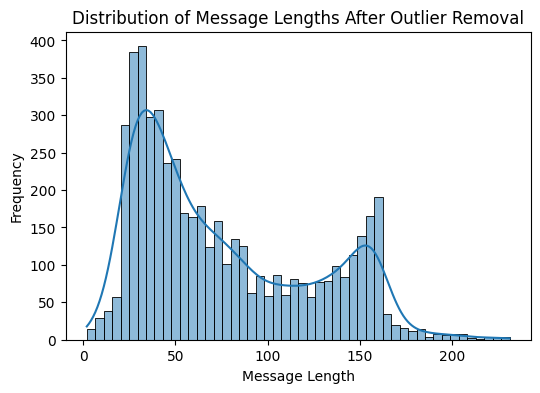

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.histplot(df['message_length'], bins=50, kde=True)
plt.title('Distribution of Message Lengths After Outlier Removal')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.show()

--Confusion Matrix

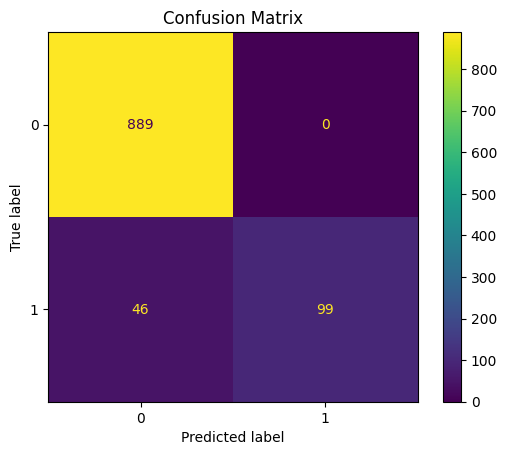

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_nb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

--Accuracy Comparison Test

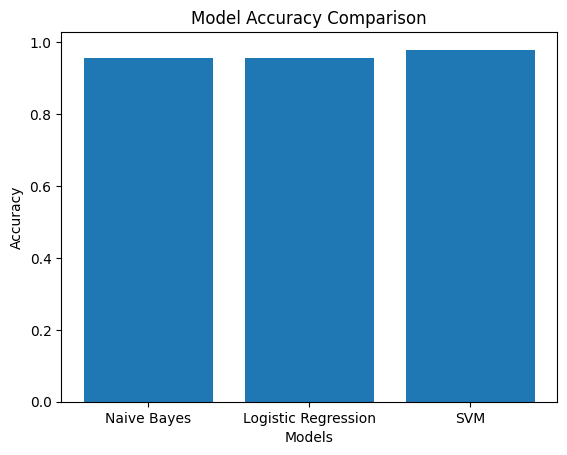

In [28]:
models = ["Naive Bayes","Logistic Regression","SVM"]

accuracy = [
accuracy_score(y_test,pred_nb),
accuracy_score(y_test,pred_lr),
accuracy_score(y_test,pred_svm)
]

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()

7. GUI Implementation

In [42]:
!pip install gradio -qq

In [43]:
import gradio as gr

def predict_spam(message):

    cleaned_message = clean_text(message)

    transformed_message = tfidf.transform([cleaned_message])

    prediction = best_model.predict(transformed_message)[0]

    return 'spam' if prediction == 1 else 'ham'

interface = gr.Interface(
    fn=predict_spam,
    inputs=gr.Textbox(lines=5, placeholder="Enter your message here..."),
    outputs="text",
    title="Spam SMS Detector",
    description="Enter an SMS message to predict if it is spam or ham."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://47762c4871e479540a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
